In [18]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [19]:
from src.evaluation.metrics import build_predictions_report

In [20]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [21]:
LEVEL = 'level_12_daily_item_store'
TARGET = 'sales'

In [22]:
import joblib

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

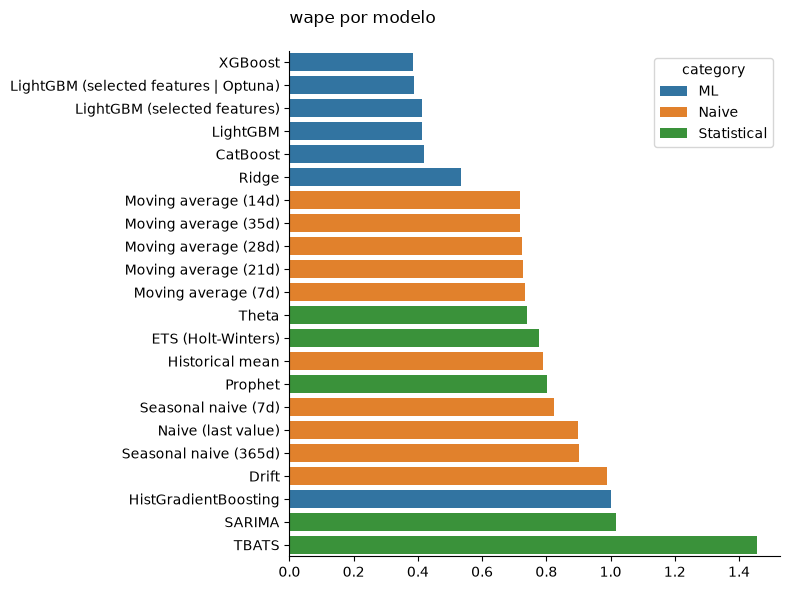

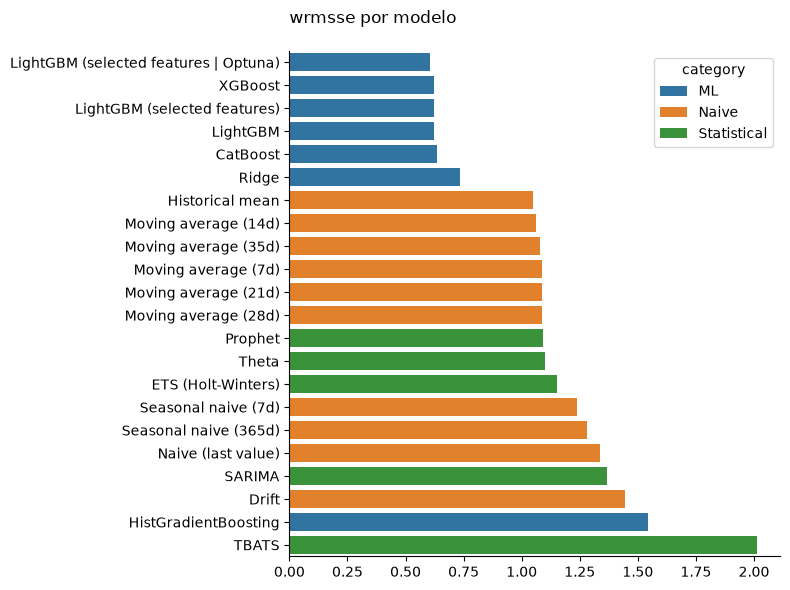

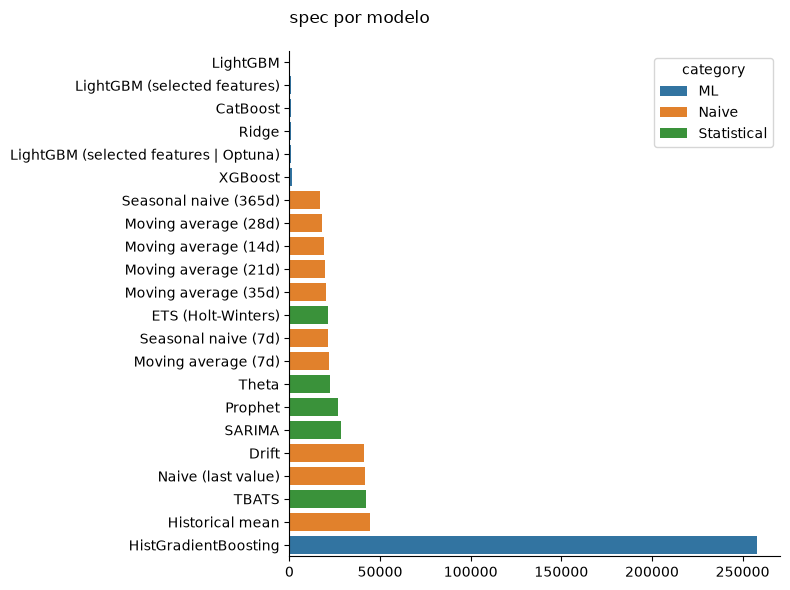

In [23]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [24]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(30_000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
2                     avg_sell_price       7.039329
10                      price_vs_max       4.124091
5                      price_vs_mean       3.984155
30                              lag1       0.106279
24                       zero_streak       0.099506
..                               ...            ...
14                   days_to_closure       0.000169
56   rolling_min_lag28_window_size28       0.000094
75  rolling_min_lag364_window_size91       0.000078
64   rolling_min_lag91_window_size28       0.000059
68   rolling_min_lag91_window_size91       0.000044

[80 rows x 2 columns]


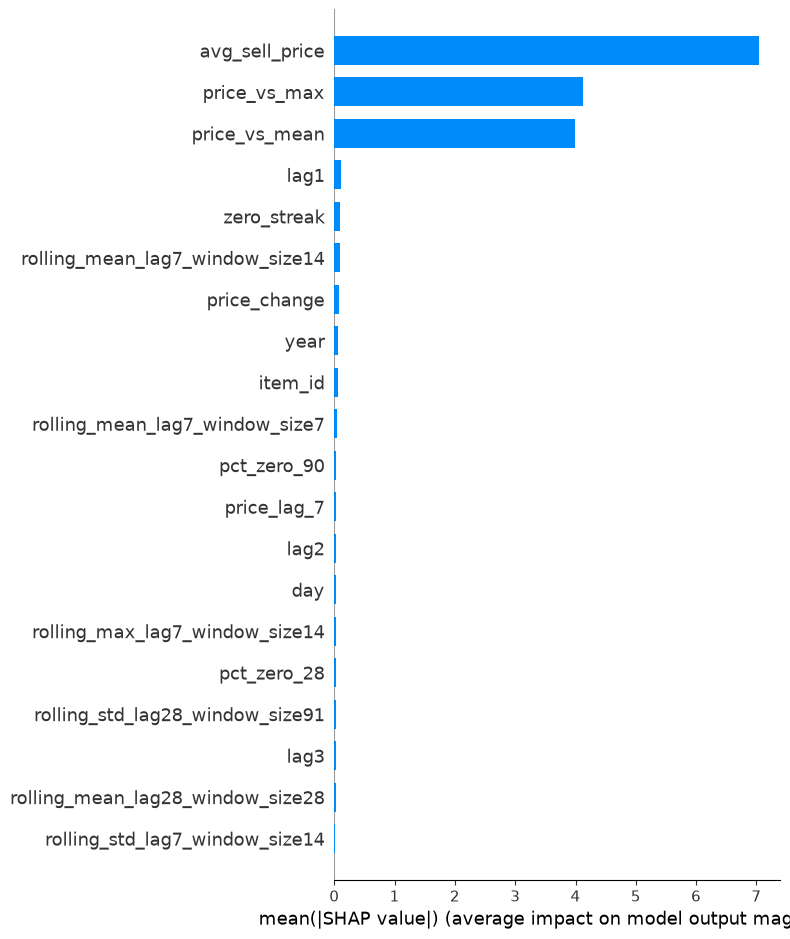

In [25]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

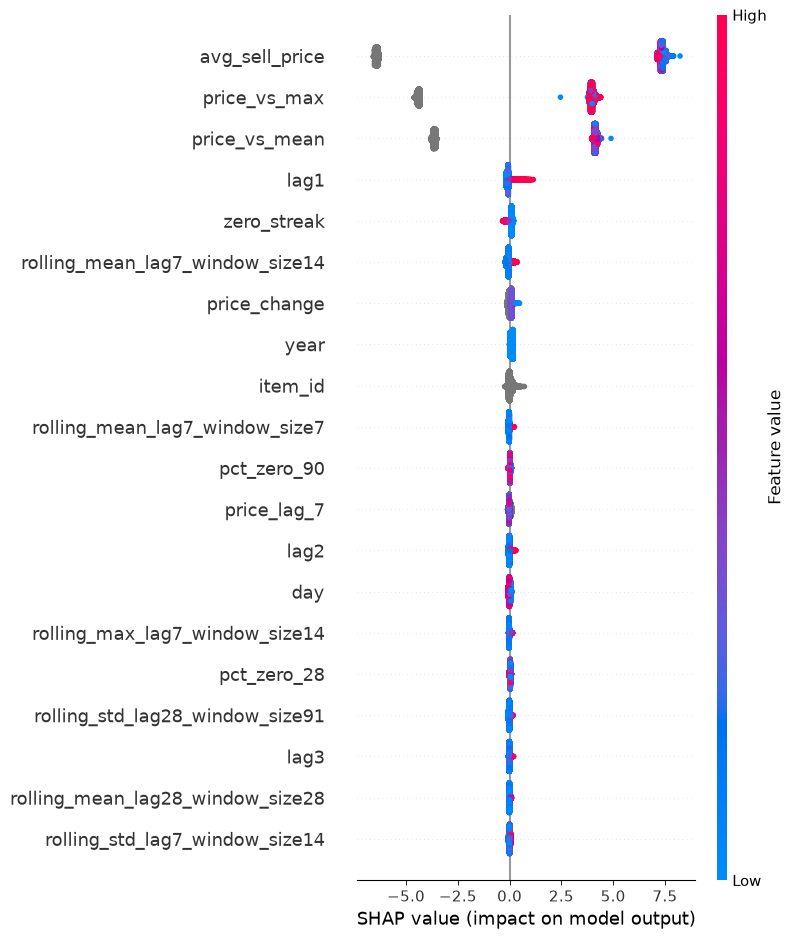

In [26]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [27]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, test=artifact['test'], target=artifact['target'],
                         explainer=explainer, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, target, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [28]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 38.65%
Test WRMSSE: 0.5363


In [29]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(10)

/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return (y_pred - y_true).sum() / np.abs(y_true).sum()


,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_FOODS_3_120_CA_3_CA,28,28,1617.0,1816.0,-199.0,373.0,8052.660156,0.041328,0.230674,0.123067,0.365437,-14.938338,0.545522,0.810152,31.169643
FOODS_3_FOODS_FOODS_3_090_CA_3_CA,28,28,3357.0,3586.0,-229.0,603.0,5371.200195,0.027566,0.179625,0.068216,0.227947,-10.633499,0.355046,0.501464,26.848214
FOODS_3_FOODS_FOODS_3_586_CA_3_CA,28,28,1883.0,1879.0,4.0,220.0,3163.439941,0.016236,0.116835,-0.002124,0.140949,0.509091,0.610260,0.556752,5.883929
FOODS_3_FOODS_FOODS_3_202_CA_3_CA,28,28,560.0,606.0,-46.0,146.0,2620.800049,0.013451,0.260714,0.082143,0.287645,-8.821918,0.486845,0.570393,18.857143
FOODS_3_FOODS_FOODS_3_252_CA_3_CA,28,28,1405.0,1303.0,102.0,290.0,2219.899902,0.011393,0.206406,-0.072598,0.227624,9.848276,0.900760,0.905431,47.294643
FOODS_3_FOODS_FOODS_3_587_CA_3_CA,28,28,876.0,943.0,-67.0,183.0,2172.479980,0.011150,0.208904,0.076484,0.253922,-10.251366,0.549932,0.615201,13.276786
FOODS_3_FOODS_FOODS_3_702_CA_3_CA,28,28,696.0,562.0,134.0,210.0,2088.000000,0.010716,0.301724,-0.192529,0.414789,17.866667,1.443873,1.459985,168.830357
FOODS_3_FOODS_FOODS_3_511_CA_3_CA,28,28,290.0,292.0,-2.0,78.0,2024.199951,0.010389,0.268966,0.006897,0.395012,-0.717949,0.681032,0.999455,3.714286
FOODS_3_FOODS_FOODS_3_444_CA_3_CA,28,19,281.0,292.0,-11.0,79.0,1961.380005,0.010066,0.281139,0.039146,0.238484,-3.898734,0.931340,0.853804,3.357143


In [30]:
df_metrics.head(10)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_FOODS_3_120_CA_3_CA,28,28,1617.0,1816.0,-199.0,373.0,8052.660156,0.041328,0.230674,0.123067,0.365437,-14.938338,0.545522,0.810152,31.169643
FOODS_3_FOODS_FOODS_3_090_CA_3_CA,28,28,3357.0,3586.0,-229.0,603.0,5371.200195,0.027566,0.179625,0.068216,0.227947,-10.633499,0.355046,0.501464,26.848214
FOODS_3_FOODS_FOODS_3_586_CA_3_CA,28,28,1883.0,1879.0,4.0,220.0,3163.439941,0.016236,0.116835,-0.002124,0.140949,0.509091,0.610260,0.556752,5.883929
FOODS_3_FOODS_FOODS_3_202_CA_3_CA,28,28,560.0,606.0,-46.0,146.0,2620.800049,0.013451,0.260714,0.082143,0.287645,-8.821918,0.486845,0.570393,18.857143
FOODS_3_FOODS_FOODS_3_252_CA_3_CA,28,28,1405.0,1303.0,102.0,290.0,2219.899902,0.011393,0.206406,-0.072598,0.227624,9.848276,0.900760,0.905431,47.294643
FOODS_3_FOODS_FOODS_3_587_CA_3_CA,28,28,876.0,943.0,-67.0,183.0,2172.479980,0.011150,0.208904,0.076484,0.253922,-10.251366,0.549932,0.615201,13.276786
FOODS_3_FOODS_FOODS_3_702_CA_3_CA,28,28,696.0,562.0,134.0,210.0,2088.000000,0.010716,0.301724,-0.192529,0.414789,17.866667,1.443873,1.459985,168.830357
FOODS_3_FOODS_FOODS_3_511_CA_3_CA,28,28,290.0,292.0,-2.0,78.0,2024.199951,0.010389,0.268966,0.006897,0.395012,-0.717949,0.681032,0.999455,3.714286
FOODS_3_FOODS_FOODS_3_444_CA_3_CA,28,19,281.0,292.0,-11.0,79.0,1961.380005,0.010066,0.281139,0.039146,0.238484,-3.898734,0.931340,0.853804,3.357143


In [31]:
df_pred.query('agg_id == "FOODS_3_FOODS_FOODS_3_120_CA_3_CA"').nlargest(10, 'wape')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
230971,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-15,20.0,99.599998,77.0,-57.0,57.0,2.850000,2.850000
230978,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-22,33.0,164.339996,66.0,-33.0,33.0,1.000000,1.000000
230968,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-12,31.0,154.380005,61.0,-30.0,30.0,0.967742,0.967742
230964,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-08,48.0,239.039993,81.0,-33.0,33.0,0.687500,0.687500
230972,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-16,30.0,149.399994,47.0,-17.0,17.0,0.566667,0.566667
230961,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-05,52.0,258.959991,72.0,-20.0,20.0,0.384615,0.384615
230954,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-04-28,46.0,229.080002,61.0,-15.0,15.0,0.326087,0.326087
230976,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-20,41.0,204.179993,54.0,-13.0,13.0,0.317073,0.317073
230956,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-04-30,93.0,463.140015,69.0,24.0,24.0,0.258065,-0.258065
230958,FOODS_3_FOODS_FOODS_3_120_CA_3_CA,2016-05-02,59.0,293.820007,74.0,-15.0,15.0,0.254237,0.254237


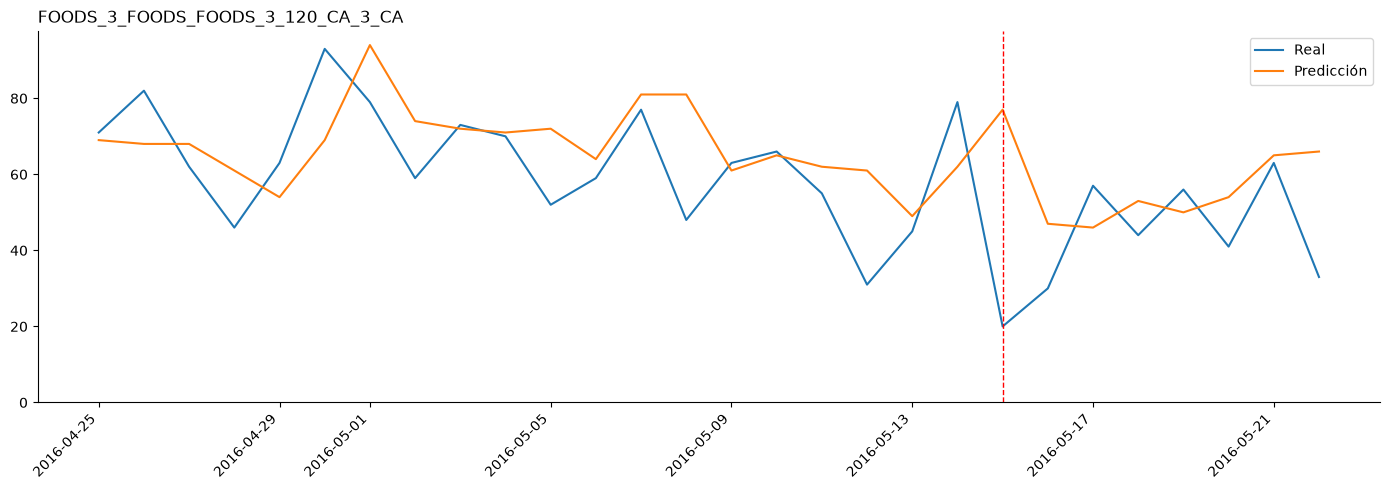

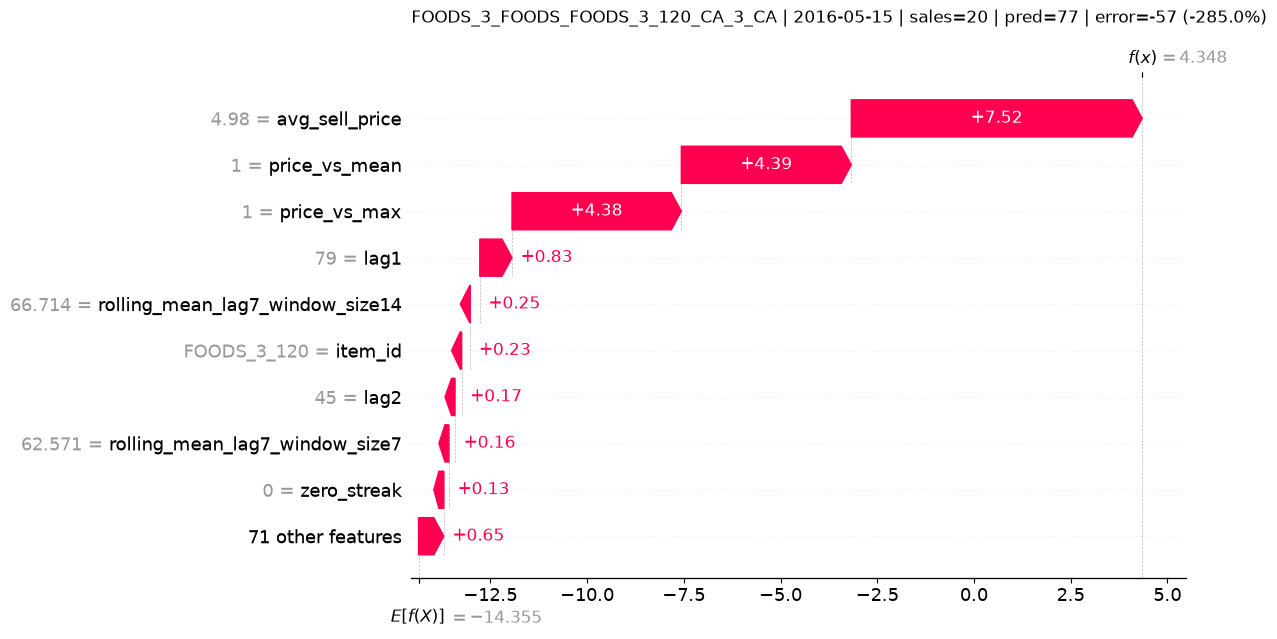

In [32]:
analizar_prediccion(agg_id='FOODS_3_FOODS_FOODS_3_120_CA_3_CA',date='2016-05-15')